## Exteroceptive

### Hyperparameters

In [1]:
NUM_EVALS = 25 # Reduce for final training for less feedback.
NUM_TIMESTEPS = 200_000_000  # Total number of training steps
EXTEROCEPTIVE = True  # Whether to use exteroceptive observations
CURRICULUM_LEARNING = True # Whether to use curriculum learning during training

### Setup

In [2]:
import os
import json

import dill
from IPython.display import Audio, display, Javascript
os.makedirs("policies", exist_ok=True)
beep_js = """
    var audio = new Audio('https://actions.google.com/sounds/v1/alarms/beep_short.ogg');
    audio.play();
"""


# Unset LD_LIBRARY_PATH to avoid conflicts
if 'LD_LIBRARY_PATH' in os.environ:
    os.environ['LD_LIBRARY_PATH'] = ''
    print("LD_LIBRARY_PATH has been unset")
else:
    print("LD_LIBRARY_PATH was not set")

# Set EGL vendor directory to include user location
user_vendor_dir = os.path.expanduser('~/.local/share/glvnd/egl_vendor.d')
os.makedirs(user_vendor_dir, exist_ok=True)

# Create ICD config for NVIDIA EGL
icd_config = {
    "file_format_version": "1.0.0",
    "ICD": {
        "library_path": "libEGL_nvidia.so.0"
    }
}
with open(f'{user_vendor_dir}/10_nvidia.json', 'w') as f:
    json.dump(icd_config, f, indent=2)

# Set environment variable for EGL vendor library dirs
current_dirs = os.environ.get('__EGL_VENDOR_LIBRARY_DIRS', '/usr/share/glvnd/egl_vendor.d')
os.environ['__EGL_VENDOR_LIBRARY_DIRS'] = f'{user_vendor_dir}:{current_dirs}'

# Set MuJoCo to use EGL
os.environ['MUJOCO_GL'] = 'egl'

# Tell XLA to use Triton GEMM for JAX
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags


import functools
from datetime import datetime
import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
from ml_collections import config_dict
from mujoco_playground import registry, wrapper
from mujoco_playground.config import locomotion_params
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import losses as ppo_losses
from IPython.display import HTML, clear_output
import custom_ppo_train
from utils import render_video_during_training, evaluate_policy
import mujoco
from custom_env import Joystick


# Function that returns a configuration dictionary for the environment and reward settings.
def reward_config() -> config_dict.ConfigDict:
  return config_dict.create(
      ctrl_dt=0.02, # Control timestep (seconds) — how often the policy acts.
      sim_dt=0.004, # Physics simulation timestep (seconds) — how often the physics engine updates.
      episode_length=1000, # Number of control steps per episode.
      # Proportional and derivative gains for the robot’s joint controllers.
      Kp=35.0, 
      Kd=0.5,
      action_repeat=1, # How many simulation steps to repeat each action.
      action_scale=1.0, # Scaling factor for actions.
      history_len=1, # How many previous observations/actions are included in the state.
      soft_joint_pos_limit_factor=0.95, # Soft limit for joint positions (as a fraction of the hard limit).
      noise_config=config_dict.create( # Adds noise to the simulation for robustness.
          level=1.0, # Overall noise level.
          scales=config_dict.create( # Per-signal noise scales
              joint_pos=0.03, # Noise on joint positions.
              joint_vel=1.5, # Noise on joint velocities.
              gyro=0.2, # Noise on gyroscope readings.
              gravity=0.05, # Noise on gravity.
              linvel=0.1, # Noise on linear velocities.
              extero=0.05, # Noise on exteroceptive (external) sensors    NEW
          ),
      ),
      reward_config=config_dict.create( # Contains all reward-related settings.
        ### ----- ADJUST SETTINGS BELOW ----- ###
          scales=config_dict.create(
              torso_height=-0.0, # Reward/penalize torso height
              # Tracking.
              tracking_lin_vel=5.0, # Reward for matching commanded linear velocity
              tracking_ang_vel=0.5, # Reward for matching commanded angular velocity.

              # Base reward.
              lin_vel_z=-0.1, # Penalty for vertical (z) velocity (encourages staying level).
              ang_vel_xy=-0.05, # Penalty for roll/pitch angular velocity (encourages stability).
              orientation=-1.0, # Strong penalty for bad orientation (falling over).
              # Other.
              dof_pos_limits=-1.0, # Penalty for exceeding joint limits.
              pose=0.5, # Reward for maintaining a good pose.
              # Other.
              termination=-1.0, # Penalty for episode termination (e.g., falling).
              stand_still=-2.0, # Penalty for not moving (encourages movement).
              # Regularization.
              torques=-0.0002, # Penalty for using large joint torques (avoid damaging motors)
              action_rate=-0.02, # Penalty for rapid changes in actions (encourages smooth movements)
              energy=-0.001, # Penalty for total energy consumption (encourages efficient locomotion)
              # Feet.
              feet_clearance=0.2, # Negative weight penalizes the robot for not lifting its feet high enough
              feet_slip=-0.1, # Penalty for feet slipping (encourage stable foot placement)
              feet_air_time=0.6, # Reward for keeping feet in the air (encourage stepping over obstacles)
              knee_collisions=-0.0 # Penalty for knee colliding with walls # TUNE
          ),
          tracking_sigma=0.25, # Standard deviation for velocity tracking reward; controls tolerance for tracking errors.
          max_foot_height=0.19, # Maximum allowed foot height (meters); helps ensure feet lift high enough to clear obstacles.        
          desired_foot_air_time=0.15, # Target time for each foot to stay in the air; encourages stepping and dynamic movement.
          desired_torso_height=0.36 # Desired torso height (meters); helps maintain balance and upright posture during locomotion.
        ### ----- ADJUST SETTINGS ABOVE ----- ###
      ),
      pert_config=config_dict.create(
          enable=False,
          velocity_kick=[0.0, 3.0],
          kick_durations=[0.05, 0.2],
          kick_wait_times=[1.0, 3.0],
      ),
      command_config=config_dict.create(
          # Uniform distribution for command amplitude.
          a=[1.5, 0.8, 1.2],
          # Probability of not zeroing out new command.
          b=[0.9, 0.25, 0.5],
      ),
      impl="jax",
      nconmax=4 * 8192,
      njmax=40,
  )

print("JAX devices:", jax.devices())

LD_LIBRARY_PATH has been unset
JAX devices: [CudaDevice(id=0)]


### Training

You can reduce the final training time by configuring less frequent evaluations (and thus less frequent video generations), but to get started it's helpful to get a lot of feedback.

You can also reduce the total training time if you feel like you have a good policy after few steps. The default is 200.000.000 steps of training.

In [3]:
xml_path = 'custom_env.xml'
env = Joystick(xml_path=xml_path, config=reward_config(), curriculum_learning=CURRICULUM_LEARNING, total_steps=NUM_TIMESTEPS, exteroceptive=EXTEROCEPTIVE)
key = jax.random.PRNGKey(15)

# ---- TEMPORARY DEBUG ----
env_name = 'Go1JoystickRoughTerrain'
randomizer = registry.get_domain_randomizer(env_name)
# randomizer = registry.get_domain_randomizer(xml_path) # CHECK if this is correct
# -------------------------
print(f"Environment '{xml_path}' loaded successfully.")

x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

current_policy = None

env_cfg = reward_config()

eval_env_for_video = Joystick(xml_path=xml_path, config=reward_config(), exteroceptive=EXTEROCEPTIVE)
jit_reset = jax.jit(eval_env_for_video.reset)
jit_step = jax.jit(eval_env_for_video.step)


def progress(num_steps, metrics):
    clear_output(wait=True)

    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"Exteroceptive Training: reward={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="red")
    
    display(plt.gcf())

    # Render video if we have a current policy
    if current_policy is not None:
        render_video_during_training(current_policy, num_steps, jit_step, jit_reset, env_cfg, eval_env_for_video)

# PPO training parameters - you may want to tune these for challenging terrain
# ---- TEMPORARY DEBUG ----
ppo_params = locomotion_params.brax_ppo_config(env_name)
#ppo_params = locomotion_params.brax_ppo_config(xml_path) # CHECK if this is correct
# -------------------------

ppo_training_params = dict(ppo_params)

ppo_training_params["num_evals"] = NUM_EVALS # Reduce for final training for less feedback.
ppo_training_params["num_timesteps"] = NUM_TIMESTEPS  # Total number of training steps


network_factory = ppo_networks.make_ppo_networks

if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

print("Training parameters:")
print(ppo_training_params)

# Create a policy parameters callback to capture the current policy
def policy_params_callback(_, make_policy_fn, params):
    global current_policy
    current_policy = make_policy_fn(params, deterministic=True)
    
train_fn = functools.partial(
        custom_ppo_train.train,
        **ppo_training_params,
        network_factory=network_factory,
        randomization_fn=randomizer,
        progress_fn=progress,
        policy_params_fn=policy_params_callback,
)

Environment 'custom_env.xml' loaded successfully.
Training parameters:
{'action_repeat': 1, 'batch_size': 256, 'discounting': 0.97, 'entropy_cost': 0.01, 'episode_length': 1000, 'learning_rate': 0.0003, 'max_grad_norm': 1.0, 'normalize_observations': True, 'num_envs': 8192, 'num_evals': 25, 'num_minibatches': 32, 'num_resets_per_eval': 1, 'num_timesteps': 200000000, 'num_updates_per_batch': 4, 'reward_scaling': 1.0, 'unroll_length': 20}


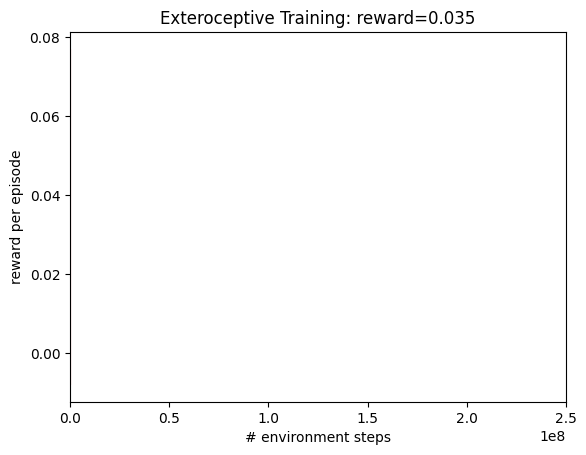

In [4]:
try:
    print("Starting exteroceptive training...")
    make_policy, params, _ = train_fn(environment=env,
                                    eval_env=Joystick(xml_path=xml_path, config=reward_config(), exteroceptive=EXTEROCEPTIVE),
                                    wrap_env_fn=wrapper.wrap_for_brax_training,
                                    compute_custom_ppo_loss_fn=ppo_losses.compute_ppo_loss
                                    )
    print("Training completed.")

    # Save policy function and parameters
    with open("policies/exteroceptive_policy_and_params.dill", "wb") as f:
        dill.dump({
            "make_policy": make_policy,
            "params": params
        }, f)

finally:
    # Play a beep sound in the browser
    display(Javascript(beep_js))

### Evaluation

In [ ]:
with open("policies/exteroceptive_policy_and_params.dill", "rb") as f:
    data = dill.load(f)
    make_policy = data["make_policy"]
    params = data["params"]

# Set up evaluation environment with challenging conditions
xml_path = 'custom_env.xml'
env_cfg = reward_config()
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [2.0, 4.0]  # Add some perturbations
env_cfg.pert_config.kick_wait_times = [3.0, 10.0]
env_cfg.command_config.a = [1.2, 0.6, 2*jp.pi]  # Adjust command ranges

#eval_env = registry.load(env_name, config=env_cfg) # OLD from lab1
eval_env = Joystick(xml_path=xml_path, config=env_cfg, exteroceptive=EXTEROCEPTIVE) # CHECK if this is correct
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick for clearer evaluation
kick_duration_range = [0.05, 0.2]

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
# deterministic = True makes the policy select the action with highest probability
# deterministic = False samples stochastically from the action distribution (used during training for exploration)
jit_inference_fn = jax.jit(make_policy(params, deterministic=True)) 

print("Evaluating policy with exteroceptive observations...")
metrics = evaluate_policy(
    eval_env,
    jit_inference_fn,
    jit_step,
    jit_reset,
    env_cfg,
    eval_env,
    velocity_kick_range,
    kick_duration_range,
)

os.makedirs("metrics", exist_ok=True)   # Check if metrics folder exists

with open("metrics/exteroceptive_metrics.dill", "wb") as f:
    dill.dump(metrics, f)